# Programming Tutorial 11 - Attention Mechanism and Transformers

```
Course: CSCI 5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```

## Overview

Sections:
- Transformer Implementation
  - Multi-head attention layer
  - Transformer block
  - Build an attention model
- Transformers on Hugging Face
  - BERT: sentiment analysis
  - GPT: text generation
  - LXMERT: visual question answering
  - Wav2Vec2: audio to text
  - ViT: image classification
- Fine-Tuning transformers

Objectives:
- Learn how to use the built-in multi-head attention layers and transformer in PyTorch
- Learn how to use Byte-Pair Encoding
- Learn how to load, run, and fine-tune transformers

In [1]:
import torch
import torch.nn as nn

## Transformer Implementation

In this section, we will implement a Transformer-like simple attention model using embedding layers and transformer blocks.

### 1. Multi-Head Attention

Recall the attention mechanism learned in the lecture. A **Scaled Dot-Product Attention** layer performs the attention computation using the inputs, $Q$, $K$, and $V$, where the results after the softmax layer is what we call an **attention map**. The **Multi-Head Attention** structure consists of multiple (i.e., $h$) attention heads.

<img src="https://aiml.com/wp-content/uploads/2023/09/Self-Attention-vs-Multi-headed-Attention.png" alt="Illustration of attention mechanism in the paper Attention Is All You Need." width="50%">

*Vaswani et al. Attention Is All You Need. NeurIPS 2017.*

In PyTorch, the implementation of the multi-head attention structure is in [`nn.MultiHeadAttention`](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html). Through the documentation, we can find that the layer returns both the layer output and the attention map (i.e., `attn_output_weights`), where the map is an averaged map in the $h$ heads:
```
multihead_attn = nn.MultiheadAttention(embed_dim, num_heads)
attn_output, attn_output_weights = multihead_attn(query, key, value)
```

Let's start with calling this layer and pass in some dummy values and observe the size of the tensors!

In [2]:
# Define parameters
embed_dim = 64   # Embedding size
num_heads = 8    # Number of attention heads
seq_length = 10  # Sequence length
batch_size = 1   # Number of sequences

# Create the MultiheadAttention layer
multihead_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

# Create dummy input tensors (query, key, value)
x = torch.randn(batch_size, seq_length, embed_dim)  # (batch, seq_len, embed_dim)

# Apply self-attention (query = key = value)
attn_output, attn_weights = multihead_attn(x, x, x)

print("Attention Input Shape:", x.shape)  # (batch_size, seq_length, embed_dim)
print("Attention Output Shape:", attn_output.shape)  # (batch_size, seq_length, embed_dim)
print("Attention Weights Shape:", attn_weights.shape)  # (batch_size, seq_length, seq_length)

Attention Input Shape: torch.Size([1, 10, 64])
Attention Output Shape: torch.Size([1, 10, 64])
Attention Weights Shape: torch.Size([1, 10, 10])


For the each input, we perform **self-attention**, meaning it is passed into the layer as $Q$, $K$, and $V$. The shape of each output should be:

- Self-attention output: $\text{seq_length} \times \text{embed_dim}$  
  - Each element in the sequence has an **embedding of size** `embed_dim`.

- Attention map shape: $\text{seq_length} \times \text{seq_length}$  
  - This represents **self-attention values** from each query to itself.

**How Does the Shape Change?**

The change in shape occurs during **matrix multiplication of $Q$ and $K$**:
$\text{Attention Scores} = Q K^T$

Since $Q$ and $K$ both have a shape of $\text{seq_length} × \text{embed_dim}$, their matrix multiplication results in:
$(\text{seq_length} \times \text{embed_dim}) \cdot (\text{embed_dim} \times \text{seq_length}) = \text{seq_length} \times \text{seq_length}$

This produces the **attention map**, which encodes how much each token attends to every other token in the sequence.


### 2. Transformer Block


Using multi-head attention layers, we are able to build self-attention transformer blocks like the gray box illustrated below.

<img src="https://miro.medium.com/v2/resize:fit:438/1*7sjcgd_nyODdLbZSxyxz_g.png" alt="Illustration of attention mechanism in the paper Attention Is All You Need." width="25%">

*Vaswani et al. Attention Is All You Need. NeurIPS 2017.*

This block includes a multi-head attention layer followed by norm and residual connection and a feed forward layer followed by norm and residual connection.

Using the `nn.MultiHeadAttention` layer, let's now implement a self-attention block.

To prevent overfitting, we apply dropout layers after the multi-head attention layer and the feed forward layer. Don't forget to **save the attention map**. While this isn't necessary for the model forward and backward, we will be using this information later for visualization.

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, hidden_dim, dropout=0.1):
        super().__init__()

        # Multi-Head Self-Attention
        self.self_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        # Two Layer Normalization
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Feedforward Network (FFN)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Multi-Head Self-Attention -> Residual & Norm
        attn_output, attn_weights = self.self_attn(x, x, x, attn_mask=mask)  # Get attention weights
        x = self.norm1(x + self.dropout(attn_output))

        # Feedforward -> Residual & Norm
        ff_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attn_weights  # Return both output and attention weights for visualization

Let's pass in dummy values again to see the tensor shapes. They should be the same as in a multi-head attention layer.

In [4]:
# Define parameters
embed_dim = 64   # Embedding size
num_heads = 8    # Number of attention heads
seq_length = 10  # Sequence length
hidden_dim = 256 # Hidden state size
batch_size = 1   # Number of sequences

transformer_block = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, hidden_dim=hidden_dim)
x = torch.randn(batch_size, seq_length, embed_dim)
block_output, attn_weights = transformer_block(x)

print("Transformer Block Input Shape:", x.shape)  # (batch_size, seq_length, embed_dim)
print("Transformer Block Output Shape:", block_output.shape)  # (batch_size, seq_length, embed_dim)
print("Transformer Block Weights Shape:", attn_weights.shape)  # (batch_size, seq_length, seq_length)

Transformer Block Input Shape: torch.Size([1, 10, 64])
Transformer Block Output Shape: torch.Size([1, 10, 64])
Transformer Block Weights Shape: torch.Size([1, 10, 10])


### 3. Attention Model

#### Architecture

Using these Transformer blocks, let's build a classification model! When constructing the model, consider the following key components:

1. Embedding: Instead of using pretrained embeddings, we can train an embedding layer alongside the model. To create the embedding layer, use `nn.Embedding`, which acts as a lookup table with a shape of `(vocab_size, embed_dim)`.
  - Whether using pretrained embeddings or training from scratch, handling embeddings inside the model eliminates the need to preprocess the dataset into embeddings beforehand. This significantly reduces data preprocessing time and storage requirements.
2. Output Processing: The final Transformer block in our model produces an output of shape `(batch_size, seq_length, embed_dim)`. But how do we process this for classification?
  - In NLP classification tasks, we commonly use the hidden state of the `[CLS]` token (the first token in the sequence) as a summary representation of the input text.
  - Extract the hidden state corresponding to `[CLS]` from the final attention layer and pass it through a fully connected layer to obtain the classification output.
3. Saving Attention Maps: If you plan to visualize attention weights, remember to return attention maps in `forward`. In this case, since we will be visualizing attention, ensure the maps are stored in `attention_maps`.


In [5]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, max_seq_len, num_classes=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, hidden_dim, dropout) for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(embed_dim, num_classes)  # Output layer (for classification)

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        positions = torch.arange(0, seq_len).expand(batch_size, seq_len).to(input_ids.device)

        x = self.embedding(input_ids) + self.pos_embedding(positions)

        attention_maps = [] # store maps here
        for layer in self.transformer_layers:
            x, attn_map = layer(x)
            attention_maps.append(attn_map)

        x = x[:, 0, :]  # Take first token representation (CLS token)
        x = self.dropout(x)
        logits = self.fc_out(x)  # Binary classification logits (before softmax)

        return logits, attention_maps

#### IMDB Dataset




In Coding Tutorial 10, we introduced the Hugging Face library. In this tutorial, we will load an NLP dataset from the Hugging Face library to train our model.

The datasets module in Hugging Face offers a vast collection of NLP datasets. To explore available datasets, visit the [datasets tab](https://huggingface.co/datasets?modality=modality:text&sort=trending), where you can filter by categories such as "text" or "classification" to find relevant datasets.




In [6]:
!pip install datasets

We'll be using the [IMDB dataset](https://huggingface.co/datasets/stanfordnlp/imdb) for sentiment classification. This dataset consists of movie reviews labeled as either positive or negative.

To load a dataset from Hugging Face, copy the dataset name from the webpage (e.g., `stanfordnlp/imdb`) and use `datasets.load_dataset` to import it into your script.

In [7]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb") # Load IMDB dataset

print('Train size:', len(dataset['train']))
print('Test size:', len(dataset['test']))
print('Text data:', dataset['train'][0]['text'])
print('Label:', dataset['train'][0]['label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size: 25000
Text data: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex 

In [8]:
dataset['train'][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

#### Tokenization: Byte-Pair Encoding

In the last tutorial, we explore multiple tokenization methods. Today, we'll be using a new method, Byte-Pair Encoding.

This method tokenizes words from text data and adds special tokens: `[CLS]` at the beginning to indicate the start of a sequence and `[SEP]` at the end to mark its termination. It is a common practice to standardize the length of all input samples. By setting a maximum sequence length (`max_length=max_seq_len`), we can ensure that:
- Longer sequences are truncated (`truncation=True`)
- Shorter sequences are padded with `[SEP] `(`padding='max_length'`)

We will be applying this pretrained encoding model from Hugging Face directly: [`bert-base-uncased`](https://huggingface.co/google-bert/bert-base-uncased).


In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Type any examples to see the tokenization results:
text = 'Tokenization using Byte-Pair Encoding!'
tokens = tokenizer.tokenize(text)
print(tokens)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['token', '##ization', 'using', 'byte', '-', 'pair', 'encoding', '!']


In [10]:
# Create tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Tokenize text
max_seq_len = 256
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=max_seq_len)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [11]:
print('Train size:', len(tokenized_datasets['train']))
print('Test size:', len(tokenized_datasets['test']))
print('Text data:', tokenized_datasets['train'][0]['input_ids'])
print('Label:', tokenized_datasets['train'][0]['label'])

Train size: 25000
Test size: 25000
Text data: [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036, 2657, 2008, 2012, 2034, 2009, 2001, 8243, 2011, 1057, 1012, 1055, 1012, 8205, 2065, 2009, 2412, 2699, 2000, 4607, 2023, 2406, 1010, 3568, 2108, 1037, 5470, 1997, 3152, 2641, 1000, 6801, 1000, 1045, 2428, 2018, 2000, 2156, 2023, 2005, 2870, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1996, 5436, 2003, 8857, 2105, 1037, 2402, 4467, 3689, 3076, 2315, 14229, 2040, 4122, 2000, 4553, 2673, 2016, 2064, 2055, 2166, 1012, 1999, 3327, 2016, 4122, 2000, 3579, 2014, 3086, 2015, 2000, 2437, 2070, 4066, 1997, 4516, 2006, 2054, 1996, 2779, 25430, 14728, 2245, 2055, 3056, 2576, 3314, 2107, 2004, 1996, 5148, 2162, 1998, 2679, 3314, 1999, 1996, 2142, 2163, 1012, 1999, 2090, 4851, 8801, 1998, 6623, 7939, 4697, 3619, 1997, 8947, 2055, 2037, 10740, 2006, 4331, 1010, 2016, 2

In [14]:
tokenized_datasets['train'][0].keys()

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])

To easily pass data into `DataLoader`, we can create our own dataset by inheriting the `Dataset` class in PyTorch. In this class, define:
- The size of the dataset in `__len__`
- The unpacked data through and index `ind`, return x (i.e., input_ids) and y (i.e., label) in `__getitem__`

In [15]:
from torch.utils.data import DataLoader, Dataset

class IMDBDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        input_ids = torch.tensor(item["input_ids"])
        label = torch.tensor(item["label"])
        return input_ids, label

# Create dataset splits
train_dataset = IMDBDataset(tokenized_datasets['train'])
test_dataset = IMDBDataset(tokenized_datasets['test'])

# Set up dataloader for batches
batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [17]:
train_dataset[0]

(tensor([  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
          2678,  3573,  2138,  1997,  2035,  1996,  6704,  2008,  5129,  2009,
          2043,  2009,  2001,  2034,  2207,  1999,  3476,  1012,  1045,  2036,
          2657,  2008,  2012,  2034,  2009,  2001,  8243,  2011,  1057,  1012,
          1055,  1012,  8205,  2065,  2009,  2412,  2699,  2000,  4607,  2023,
          2406,  1010,  3568,  2108,  1037,  5470,  1997,  3152,  2641,  1000,
          6801,  1000,  1045,  2428,  2018,  2000,  2156,  2023,  2005,  2870,
          1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  1996,
          5436,  2003,  8857,  2105,  1037,  2402,  4467,  3689,  3076,  2315,
         14229,  2040,  4122,  2000,  4553,  2673,  2016,  2064,  2055,  2166,
          1012,  1999,  3327,  2016,  4122,  2000,  3579,  2014,  3086,  2015,
          2000,  2437,  2070,  4066,  1997,  4516,  2006,  2054,  1996,  2779,
         25430, 14728,  2245,  2055,  3056,  2576,  

### 4. Model Training

Now, we are ready to train the model! Let's create a model with one transformer block (i.e., `num_layers = 1`).

In [ ]:
import torch.optim as optim

# Define model hyperparameters
vocab_size = tokenizer.vocab_size # Get vocab size from tokenizer
embed_dim = 128
num_heads = 8
hidden_dim = 256
num_layers = 1
num_classes = 2
learning_rate = 2e-5
num_epochs = 10

# Initialize
model = TransformerClassifier(vocab_size, embed_dim, num_heads, hidden_dim,
                              num_layers, max_seq_len, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for input_ids, labels in train_dataloader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")

Epoch 1 - Loss: 0.692744
Epoch 2 - Loss: 0.615938
Epoch 3 - Loss: 0.581529
Epoch 4 - Loss: 0.562073
Epoch 5 - Loss: 0.545232
Epoch 6 - Loss: 0.525488
Epoch 7 - Loss: 0.501483
Epoch 8 - Loss: 0.481570
Epoch 9 - Loss: 0.467126
Epoch 10 - Loss: 0.450249


### 5. Evaluation

Evaluate the model on test set. The function [`sklearn.metrics.accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) is similar to `torchmetrics.Accuracy`. As `sklearn` is preinstalled on Colab, we will use this function to calculate accuracy here.

In [ ]:
from sklearn.metrics import accuracy_score

model.eval()
predictions, true_labels = [], []

with torch.no_grad():
    for input_ids, labels in test_dataloader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        logits, _ = model(input_ids)
        preds = torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7685


### 6. Visualize Attention Maps

To visualize attention, plot the attention values from the multi-head attention layer(s).

Recall that the attention map has dimensions of `seq_length` by `seq_length`, where `seq_length` is set to 256 in our model. Let’s visualize the attention map for `[CLS]` (i.e., the first token) to examine how it attends to each token in the sentence. For simplicity, we will ignore padding tokens at the end of the sequence.

In [ ]:
def attention_map(input_text):
    print('\nInput text: {}'.format(sample_text))

    # Tokenize the input
    tokens = tokenizer(input_text, padding='max_length', truncation=True,
                       max_length=max_seq_len, return_tensors="pt")
    input_ids = tokens['input_ids'].to(device)

    # Prepare token cound and words for visualization
    valid_token_count = (tokens['input_ids'] != tokenizer.pad_token_id).sum().item() - 1
    words = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).tolist())

    # Predict: get prediction and attention maps
    with torch.no_grad():
        logits, attention_maps = model(input_ids)
        preds = torch.argmax(logits, dim=1)
        prediction = 'Positive' if preds.cpu().numpy()[0] == 1 else 'Negative'
        print('Prediction: {}'.format(prediction))
        attn_weights = [m.squeeze(0).detach().cpu().numpy() for m in attention_maps]

    # Plot attention heatmap for each layer
    for l in range(num_layers):
        plt.figure(figsize=(12, 0.5))
        visualize_map = attn_weights[l][:1, 1:valid_token_count]
        sns.heatmap(visualize_map, xticklabels=words[1:valid_token_count], yticklabels=words[:1],
                    cmap="Blues", annot=True)
        plt.title(f'Layer {l+1}')
        plt.show()


Input text: The movie was absolutely amazing and I loved it.
Prediction: Positive


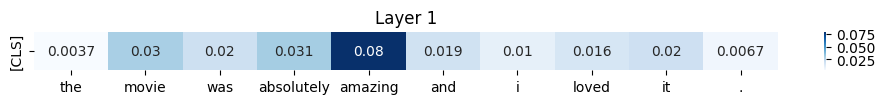


Input text: Terrible movie...one of the worst
Prediction: Negative


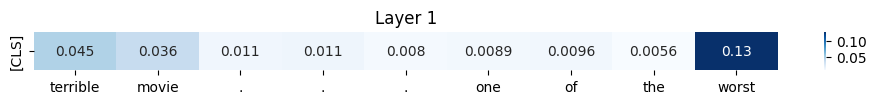


Input text: Excellent cast!! Brad Pitt is gorgeous!!
Prediction: Positive


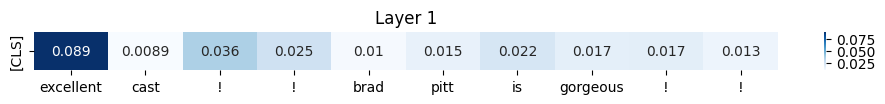


Input text: Bad bad bad bad bad movie 
Prediction: Negative


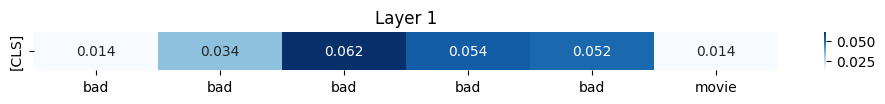

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_text = 'The movie was absolutely amazing and I loved it.'
attention_map(sample_text)

sample_text = 'Terrible movie...one of the worst'
attention_map(sample_text)

sample_text = 'Excellent cast!! Brad Pitt is gorgeous!!'
attention_map(sample_text)

sample_text = 'Bad bad bad bad bad movie '
attention_map(sample_text)

We can see that the `[CLS]` token attends to the words in the sentence that can help determine the tone. For instance, "loved", "terrible", "worst", excellent", "gorgeous", and "bad".

## Transformers on Hugging Face

### Hugging Face

Hugging Face has revolutionized NLP and deep learning by making state-of-the-art AI models easily accessible, reusable, and trainable. The `transformers` library provides resources in modern AI models, and the `datasets` library provides ready-to-use, well-structured datasets instead of searching the internet for datasets.

The `datasets` library was introduced in Coding Tutorial 9, so in this tutorial, we will focus on the `transformers` library. It is an open-source library that provides pre-trained AI models and various utilities for working with those models. Through five examples, BERT, GPT, LXMERT, Qav2Vet and ViT, this tutorial demonstrates loading, evalutating, and fine-tuning models available in `transformers`. Note that many of the the state-of-the-art models are still being added to Hugging Face as new methods are proposed. Through the steps we are about to go through, you are given the opportunity to efficiently setup new and powerful models.

For installation, you need to install the two libraries separately:
```
pip install transformers
pip install datasets
```
Hugging Face also has the [`tokenizers`](https://huggingface.co/docs/tokenizers/en/index) library for fast and effecient tokenization, but you can also use `transformers`'s built-in tokenizers as we did in Coding Tutorial 9. There is the library [`accelerate`](https://huggingface.co/docs/accelerate/en/index) for GPUs & TPUs acceleration. To use these libraries, additional installation is required:
```
pip install tokenizers
pip install accelerate
```

### Transformers Library


[Transformers](https://huggingface.co/docs/transformers/index): To get started, go to the [quick tour](https://huggingface.co/docs/transformers/quicktour) page to explore the Transformer library in Hugging Face and learn about how to use it. The supported models and frameworks are listed in [this page](https://huggingface.co/docs/transformers/index#supported-models-and-frameworks).

To use the model for (1) inference and (2) fine-tuning, use the following tools in this package:
- [Pipeline](https://huggingface.co/docs/transformers/quicktour#pipeline): The pipeline() is the easiest and fastest way to use a pretrained model for inference. You can use the pipeline() out-of-the-box for many tasks across different modalities. Available tasks in `pipelines` are listed in the [index](https://huggingface.co/docs/transformers.js/en/pipelines#available-tasks).
- [AutoTokenizer](https://huggingface.co/docs/transformers/quicktour#autotokenizer): A tokenizer is responsible for preprocessing text into an array of numbers as inputs to a model, and both
- [AutoModel](https://huggingface.co/docs/transformers/quicktour#automodel): Transformers provides a simple and unified way to load pretrained instances.

To further breakdown how to utilize `transformers`, see the steps below:

**Step 1: Pipeline for inference** ([documentation](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.pipeline))
1. Read about how to call `pipeline`
2. See the list of the existing tasks in the API and documentations. Select a task that you want to run (e.g., `text-classification`)
3. If a model is not specified, a default model is called. To view available models, go to the [Models page](https://huggingface.co/models) on Hugging Face and select the corresponding task (e.g., for `text-classification`, you can find available models by selecting `Text Classification` under `NLP` category).

**Step 2: AutoClasses for fine-tuning** ([documentation](https://huggingface.co/docs/transformers/quicktour#autoclass))
1. First, prepare the dataset for training. Use the class `AutoTokenizer` to create a tokenizer based on the model you are training. You can process your dataset using this tokenizer before feeding it to the model. For the available frameworks (e.g., PyTorch, Tensorflow), select one that applies.
2. To load the model, use `AutoModel` to load the pretrained off-the-shelf model in either PyTorch or Tensorflow, and use the tokenized data to fine-tune the model.

Now, we will explore using the **trained models** on Hugging Face.

### Sentiment Analysis - BERT

In `pipeline`, the IMDB dataset we used in the previous section is called **text classification** or **sentiment analysis**. To build a sentiment analysis pipeline, use [`pipeline(task="text-classification")`](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/pipelines#transformers.TextClassificationPipeline) or `pipeline(task="sentiment-analysis")`. Through the [tasks index](https://huggingface.co/docs/transformers.js/en/pipelines#available-tasks), you can find the **text classification** row. You are able to see the pipeline document through the "doc" link, and you can see the available models through the ["models" link](https://huggingface.co/models?pipeline_tag=text-classification&library=transformers.js). All models in this link can be loaded to the text classification pipeline.

To use the default model, you can simply load the pipeline without a model specification:
```
default_pipe = pipeline("text-classification")
```

We'll be using the base BERT model: [`nlptown/bert-base-multilingual-uncased-sentiment`](https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment) in this example. To do so, we can specify the model by `model=nlptown/bert-base-multilingual-uncased-sentiment`. You are encouraged to try loading other models as well. Don't forget that there are plenty of models available in the "models" link, and they will likely keep growing as new models are proposed.

In the model documentation, it says the model is trained on six languages for sentiment prediction of the review as a number of stars (between 1 and 5).

In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')
print(classifier('I am happy today!'))

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': '5 stars', 'score': 0.7161960601806641}]


In [ ]:
print(classifier('It wasn\'t very clean..'))
print(classifier('Fantastic experience'))
print(classifier('I will never come back here'))
print(classifier('Acceptable for this price'))

[{'label': '2 stars', 'score': 0.5010057687759399}]
[{'label': '5 stars', 'score': 0.8062613010406494}]
[{'label': '1 star', 'score': 0.4826505780220032}]
[{'label': '4 stars', 'score': 0.5069335699081421}]


That was very fast and easy, right? The Hugging Face libraries integrate the deep learning frameworks and provide pipelines with high accessibility for us. Without having to build anything in PyTorch, we were able to get this model running!

### Text Generation - GPT

For the second task, let's try inference text generation! Again, find `text-generation` in the [pipeline index](https://huggingface.co/docs/transformers.js/en/pipelines#available-tasks), and see what models are available through the ["models" link](https://huggingface.co/models?pipeline_tag=text-generation&library=transformers.js).

Let's try loading the GPT model, [`openai-gpt`](https://huggingface.co/openai-community/openai-gpt).

In [ ]:
model_generate = pipeline('text-generation', model='openai-gpt')
print(model_generate('Today is a sunny day'))

config.json:   0%|          | 0.00/656 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/479M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

OpenAIGPTLMHeadModel LOAD REPORT from: openai-gpt
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/816k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/458k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Today is a sunny day. the sun is shining. " \n " yeah. i know. i guess i don\'t know what to say. " \n " well, you don\'t have to say anything. you can just say you like it. " \n " i don\'t know. i know it\'s not the same. " \n " you\'re probably just overwhelmed by the whole situation. " \n " i guess. " \n " go get dressed, and i \'ll have a snack for you. " \n " yeah, okay. " \n " don\'t forget your pajamas. " \n " i won\'t. " \n " i \'ll see you in a few minutes. " \n i grabbed my phone and walked back into the bathroom. i could hear my mom and dad talking as i was in the shower. i turned on the water and stepped in. the water felt so good on my skin. i closed my eyes and let it wash over me. i took a deep breath and let it out slowly. i needed to get my head back in the game. \n i walked out of the shower and grabbed a towel. i wrapped it around my body and walked into the bedroom. i grabbed some pajamas and put them on. i heard my mom talking to dad and he sou

In [ ]:
print(model_generate('I went grocery shopping yesterday and'))
print(model_generate('Taking a deep learning course in graduation school can be beneficial'))
print(model_generate('It snows in Boulder a lot, but'))

Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'I went grocery shopping yesterday and picked out a few things. i also took the liberty of buying a new pair of flip flops so i could wear them all day. \n " hey, you on the prowl? " \n " yeah, why not? " i reply. \n " you\'re going to be alone today, right? " he asks. \n " yeah, but i thought we could go shopping. " \n " you know that\'s just not safe. " \n " why not? " \n " because i haven\'t had a date in a while, " he says, and i immediately feel the need to defend him. \n " i haven\'t either, " i say, and he nods his head in agreement. \n " okay, well, maybe you can go out with me one night. " i look at him, confused. \n " go out with you? " i ask and then think about it. " no. i don\'t think that\'s a good idea. " i shake my head. \n " what do you mean? " \n " i don\'t know. i haven\'t been out in a while, but i haven\'t been out out with anyone. " \n he rubs his chin and looks down at the table. " i don\'t want you to think that i'}]


Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Taking a deep learning course in graduation school can be beneficial. " \n she was so pleased with his answer that she couldn\'t help but smile. " i will, thanks. " \n " and i don\'t mean that in the good way. i mean with the kind of work you do and the things you do. " \n " what kinds of things? " \n " i know you aren\'t a very good teacher, but you are very good. you\'re just not very talented. " \n she laughed softly. " i think i \'d like to be. " \n " you have a lot of talent. " \n she couldn\'t help but smile. " maybe. i\'m not sure. " \n " what do you do? " \n " i don\'t know. i\'m a waitress. " \n " and you\'re a teacher? " \n " i\'m an accountant. " \n " what do you do for a living? " \n " i work for my father. " \n " interesting. is he a good man? " \n she laughed. " don\'t go there. " \n " why? " \n " because i don\'t want to get into a discussion about my father. " \n " i\'m sorry. i didn\'t mean to pry. i don\'t mean to pry at all. i do'}]
[{'generated_

### VQA - LXMERT

In [ ]:
from PIL import Image
from transformers import AutoTokenizer, LxmertForQuestionAnswering


tokenizer = AutoTokenizer.from_pretrained("unc-nlp/lxmert-base-uncased")
model = LxmertForQuestionAnswering.from_pretrained("unc-nlp/lxmert-vqa-uncased").to(device)
model.eval()

question = "What animal is in the picture?"
inputs = tokenizer(question, return_tensors="pt").to(device)

# Dummy region features (shape must match what LXMERT expects)
B = inputs["input_ids"].shape[0]
num_boxes = 36
feat_dim = model.config.visual_feat_dim  # usually 2048
pos_dim  = model.config.visual_pos_dim   # usually 4

visual_feats = torch.randn(B, num_boxes, feat_dim, device=device)
visual_pos   = torch.rand(B, num_boxes, pos_dim, device=device)

with torch.no_grad():
    out = model(
        **inputs,
        visual_feats=visual_feats,
        visual_pos=visual_pos,
    )

if hasattr(out, "question_answering_score") and out.question_answering_score is not None:
    scores = out.question_answering_score  # [B, num_answers]
elif hasattr(out, "logits") and out.logits is not None:
    scores = out.logits
else:
    # Print available fields to help debug across versions
    print("Output fields:", out.keys() if hasattr(out, "keys") else dir(out))
    raise AttributeError("No QA scores found (expected question_answering_score or logits).")

pred_id = scores.argmax(dim=-1).item()

# Decode answer if mapping exists
id2label = getattr(model.config, "id2label", None) or {}
pred_answer = id2label.get(pred_id, f"(answer_id={pred_id})")

print("Q:", question)
print("Pred:", pred_answer)
print("scores shape:", tuple(scores.shape))


Loading weights:   0%|          | 0/455 [00:00<?, ?it/s]

Q: What animal is in the picture?
Pred: (answer_id=315)
scores shape: (1, 3129)


### Audio to Text - Wav2Vec2

Next, let's try to load and run a pretrained audio-to-text model on Hugging Face.

Speech recognition, also known as audio-to-text, is the process of converting spoken language into written text. It is a critical task in many real-world applications such as virtual assistants (e.g., Siri, Alexa), transcription services, and voice command systems. Modern speech recognition systems rely on deep learning models to accurately transcribe spoken words, handle different accents, and cope with noisy environments.


As instroduced in Programming Tutorial 8, the package `torchaudio` contains built-in audio datasets. For this task, we will download an audio dataset from `torchaudio` and use `transformers` for inference.


In [ ]:
!pip install torchaudio

 **Prepare Data**

Similar to `torchvision`, [`torchaudio`](https://pytorch.org/audio/2.5.0/datasets.html) has a rich collection of audio datasets. Below, let's use the dataset [`librispeech`](https://pytorch.org/audio/2.5.0/generated/torchaudio.datasets.LIBRISPEECH.html#torchaudio.datasets.LIBRISPEECH) for the audio-to-text task.

To play the audio sound in your notebook, you can use the function `IPython.display.Audio`.

In [ ]:
import torchaudio
from torchaudio.datasets import LIBRISPEECH
from IPython.display import Audio

# Load a subset of the LibriSpeech dataset
dataset = LIBRISPEECH(root=".", url="test-clean", download=True)

# Check the first sample in the dataset
print(dataset[0])
waveform, sample_rate, transcript, _, _, _ = dataset[0]
print('Sample rate: {}'.format(sample_rate))
print('Transcript: {}'.format(transcript))

# Play audio
Audio(waveform.numpy(), rate=sample_rate)

100%|██████████| 331M/331M [00:26<00:00, 13.1MB/s]


(tensor([[0.0003, 0.0003, 0.0004,  ..., 0.0021, 0.0021, 0.0016]]), 16000, 'HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE', 1089, 134686, 0)
Sample rate: 16000
Transcript: HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE


Given the `waveform` and the `sampling_rate`, the processor is able to generate a set of model inputs for your data.

For this task, we will experiment using the Hugging Face pretrained model to make predictions. There are various models available on Hugging Face for audio-to-text. We'll be using the **Wav2Vec2 model**, which is a transformer-based model developed by FacebookAI, which set new performance records on benchmarks for speech recognition tasks.

To start, explore `transformers`'s [Wav2Vec documentation](https://huggingface.co/docs/transformers/en/model_doc/wav2vec2). The key components we need here are `Wav2Vec2ForCTC` and `Wav2Vec2Processor`, wehre `Wav2Vec2ForCTC` is the Wav2Vec model class, and `Wav2Vec2Processor` is the data processor customized to this model.



In [ ]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
import torch

There are various models available on Hugging Face for audio-to-text. We'll be using the [Wav2Vec2 model](https://huggingface.co/facebook/wav2vec2-large-960h), which is a transformer-based model developed by FacebookAI, which set new performance records on benchmarks for speech recognition tasks.

In [ ]:
# Load the pre-trained Wav2Vec2 model and processor
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/404 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Before using the Hugging Face model, we need to use `processor` to process the data into the format the model requires:

In [ ]:
# Process the audio input to prepare it for the Wav2Vec2 model
inputs = processor(waveform, sampling_rate=sample_rate, return_tensors="pt", padding=True)

Now, we have the processed data, `input`. For inference, we can push a sample from `input` into the Hugging Face model, `model`:

In [ ]:
# Perform inference to get logits (output predictions from the model)
with torch.no_grad():
    logits = model(input_values=inputs.input_values[0]).logits

# Decode the predicted ids to text
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)

print("Transcription: ", transcription[0])

Transcription:  HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE


### Image Classification - ViT

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


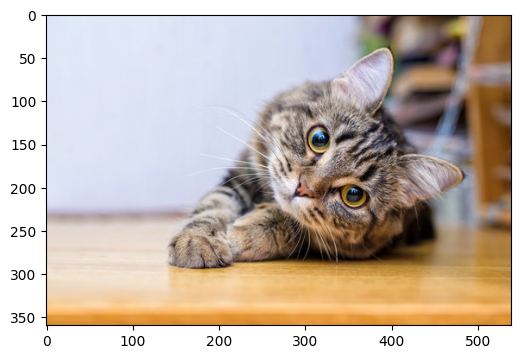

[{'label': 'tabby, tabby cat', 'score': 0.7222110629081726}, {'label': 'tiger cat', 'score': 0.1636933535337448}, {'label': 'Egyptian cat', 'score': 0.06653887778520584}, {'label': 'Persian cat', 'score': 0.030039170756936073}, {'label': 'lynx, catamount', 'score': 0.006520950235426426}]


In [ ]:
from transformers import pipeline
vit_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

from PIL import Image
import requests
import matplotlib.pyplot as plt

# Try different images below
url = 'https://t3.ftcdn.net/jpg/02/36/99/22/360_F_236992283_sNOxCVQeFLd5pdqaKGh8DRGMZy7P4XKm.jpg'
# url = 'http://farm9.staticflickr.com/8040/7928721018_0b26a5b000_z.jpg'
# url = 'http://farm4.staticflickr.com/3730/9455431370_d8b61be4e4_z.jpg'
# url = 'http://farm5.staticflickr.com/4095/4886266871_949e713af3_z.jpg'
# url = 'https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cat.png'

image = Image.open(requests.get(url, stream=True).raw)
result = vit_classifier(image)
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.show()
print(result)

## Model Fine-Tuning

The pre-trained models were trained on specific tasks and data. While convenient, these trained models might not always fit our needs. To train a model for our desired tasks, we can **fine-tune** the pre-trained models. Below, we demonstrate how to fine-tune a model.
- Model: Take the [base BERT model](https://huggingface.co/google-bert/bert-base-cased) for fine-tuning
- Dataset: Fine-tune the model on this [emotion dataset](https://huggingface.co/datasets/dair-ai/emotion) for six emotions, joy, sadness, anger, fear, love, and surprise.

In [ ]:
import datasets

dataset = datasets.load_dataset('dair-ai/emotion')

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

To train the model, you need to prepare your dataset using `AutoTokenizer`. Read about tokenizers and available options [here](https://huggingface.co/docs/transformers/v4.38.2/en/tokenizer_summary). `AutoTokenizer` returns tokenized data for model training and validation. See the documentation for coding examples (like the one below, copied from there).

```
from transformers import AutoTokenizer

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

encoding = tokenizer("We are very happy to show you the 🤗 Transformers library.")
print(encoding)
```

In [ ]:
from transformers import AutoTokenizer

model_name = 'google-bert/bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_data(data):
    return tokenizer(data['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = dataset['train'].map(preprocess_data, batched=True)
test_dataset = dataset['test'].map(preprocess_data, batched=True)

# Create subset of train and test
train_dataset_subset = train_dataset.select([i for i in range(1000)])
test_dataset_subset = test_dataset.select([i for i in range(500)])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Follow this [fine-tuning tutorial](https://huggingface.co/docs/transformers/en/training) to load the pretrained model, setup training arguments, and train the model. You will need `TrainingArguments` and `Trainer` from `transformers` for fine-tuning, and the Hugging Face library `evaluate` helps with evaluation setup.

In [ ]:
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

# Turn off wandb (you can skip this if you have a wandb account)
import os
os.environ['WANDB_DISABLED'] = 'true'

# Load model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

# For evaluation, add the argmax step
metric = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Training arguments
n_epochs = 3
training_args = TrainingArguments(output_dir='test_trainer',
                                  logging_strategy='epoch',
                                  num_train_epochs=n_epochs,
                                  report_to='none')

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_subset,
    eval_dataset=test_dataset_subset,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print("Evaluation Results:", results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
125,1.529642
250,1.057587
375,0.499435


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluation Results: {'eval_loss': 0.5928887724876404, 'eval_accuracy': 0.822, 'eval_runtime': 3.7409, 'eval_samples_per_second': 133.658, 'eval_steps_per_second': 16.841, 'epoch': 3.0}


The model performs very well within three epochs of training! This highlights the advantages **fine-tuning** brings us. Given a better starting point for model parameters, we can save time and computing resources on training.

Fine-tuning is also particularly useful for smaller datasets. Note that we only used **1000** samples from the dataset to train this model, yet, the performance on the test set is still over 80\% after three epochs. Since the model was pre-trained on large-scale datasets, it has already learned general language representations. This allows our model to adapt quickly to our specific task with minimal training data while still achieving strong performance. By leveraging transfer learning, we benefit from the knowledge embedded in the pre-trained model, reducing the need for extensive data collection and computational power.

You can increase the epochs `n_epochs` and explore how this factor impacts model performance.

## Review

Building Transformers from scratch can be a lot of work. Hugging Face is a resource-rich with various pre-trained models. For practice, we recommend browsing the model collection on Hugging Face, find a task you are interested in, load a **recent model** (posted within 2 years), and run inference on random samples.

For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley